# Query-to-template throughput benchmark

This notebook measures the repeated workflow in which a fixed bank of templates
is prepared once and then matched against many query trees to produce a score
matrix.

The primary outputs are kept separate:

- **warm throughput:** query-template pairs scored per second after reusable
  preparation;
- **one-time setup:** encoder fitting and reusable query/template preparation;
- **accuracy:** score-matrix quality relative to an agreed exact score matrix;
- **API validation:** prepared-tree and direct calls must agree on a deterministic
  sample before timings are accepted.

The default `smoke` run checks the wiring and correctness gates. Use `standard`
for substantive timing experiments.

## Imports and repository setup

Run the notebook from anywhere inside the repository checkout. The bootstrap
below locates `pyproject.toml` and places `src/` on `sys.path`; an editable
installation is still recommended.

In [1]:
from __future__ import annotations

from collections.abc import Mapping
from copy import deepcopy
from pathlib import Path
from time import perf_counter
import json
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repository_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(
        "Could not find the repository root. Run this notebook from inside the "
        "tree_matching checkout."
    )


def normalize_selection(value, *, available: list[str], setting_name: str) -> list[str]:
    if value == "all":
        selected = list(available)
    elif isinstance(value, str):
        selected = [value]
    else:
        selected = [str(item) for item in value]

    if not selected:
        raise ValueError(f"{setting_name} must select at least one item")
    if len(set(selected)) != len(selected):
        raise ValueError(f"{setting_name} contains duplicate entries: {selected}")

    unknown = sorted(set(selected).difference(available))
    if unknown:
        raise ValueError(
            f"Unknown {setting_name.lower()}: {unknown}. Available values are {available}."
        )

    selected_set = set(selected)
    return [name for name in available if name in selected_set]


def normalize_run_label(value: str | None) -> str | None:
    if value is None or not str(value).strip():
        return None
    label = str(value).strip()
    if re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9._-]*", label) is None:
        raise ValueError(
            "RUN_LABEL must start with a letter or digit and contain only letters, "
            "digits, '.', '_', or '-'."
        )
    return label


ROOT = find_repository_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from benchmarking import (  # noqa: E402
    load_config,
    resolve_algorithm_specs,
    run_throughput_config,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
print(f"Repository root: {ROOT}")


Repository root: /home/asmi28/python_code/tree_matching


## User settings

The controls below are deliberately compact. `SCALE` chooses a versioned preset;
`REGIMES` and `ALGORITHMS` select subsets without changing their preset order;
`SIZE_OVERRIDES` changes only tree size/depth fields for named regimes. Query and
template counts have separate global overrides. Use a `RUN_LABEL` for
substantive runs so outputs do not overwrite an earlier run.


In [2]:
SCALE = "standard"
RUN_LABEL = "standard_v1"
REGIMES = "all"
ALGORITHMS = "all"
SIZE_OVERRIDES = {}
N_QUERIES = None
N_TEMPLATES = None
REPEATS = None
SEED = 20260928

## Resolve the preset

`smoke` uses a very small workload. `standard` contains three repeated-workflow
regimes: common scalar labels with path templates, sparse multi-token overlap
with a bank of larger tree templates, and a smaller generic Jaccard tree-to-path
score. Selecting subsets does not change preset order. Size overrides are
limited to `n_g`, `n_h`, `depth_g`, and `depth_h`; algorithm hyperparameters
remain in named, version-controlled configurations.


In [3]:
PRESET_PATHS = {
    "smoke": ROOT / "experiments" / "path_match_throughput_quick.json",
    "standard": ROOT / "experiments" / "path_match_throughput_full.json",
}

scale_key = str(SCALE).strip().lower()
if scale_key not in PRESET_PATHS:
    raise ValueError(f"SCALE must be one of {sorted(PRESET_PATHS)}, not {SCALE!r}")

run_label = normalize_run_label(RUN_LABEL)
config = deepcopy(load_config(PRESET_PATHS[scale_key]))

all_regimes = list(config["regimes"])
available_regimes = [str(item["name"]) for item in all_regimes]
selected_names = normalize_selection(
    REGIMES,
    available=available_regimes,
    setting_name="REGIMES",
)

available_algorithms = [str(name) for name in config["algorithms"]]
selected_algorithms = normalize_selection(
    ALGORITHMS,
    available=available_algorithms,
    setting_name="ALGORITHMS",
)
config["algorithms"] = selected_algorithms

if SIZE_OVERRIDES is None:
    size_overrides = {}
elif isinstance(SIZE_OVERRIDES, Mapping):
    size_overrides = dict(SIZE_OVERRIDES)
else:
    raise TypeError("SIZE_OVERRIDES must be a mapping from regime name to overrides")

unknown_override_regimes = sorted(set(size_overrides).difference(available_regimes))
if unknown_override_regimes:
    raise ValueError(
        "SIZE_OVERRIDES contains unknown regimes: "
        f"{unknown_override_regimes}. Available regimes are {available_regimes}."
    )

allowed_size_fields = {"n_g", "n_h", "depth_g", "depth_h"}
normalized_overrides: dict[str, dict[str, int]] = {}
for regime_name, override in size_overrides.items():
    if not isinstance(override, Mapping):
        raise TypeError(f"SIZE_OVERRIDES[{regime_name!r}] must be a mapping")
    unknown_fields = sorted(set(override).difference(allowed_size_fields))
    if unknown_fields:
        raise ValueError(
            f"SIZE_OVERRIDES[{regime_name!r}] has unsupported fields {unknown_fields}; "
            f"allowed fields are {sorted(allowed_size_fields)}."
        )
    normalized = {}
    for field, value in override.items():
        integer_value = int(value)
        if integer_value < 1:
            raise ValueError(
                f"SIZE_OVERRIDES[{regime_name!r}][{field!r}] must be positive"
            )
        normalized[field] = integer_value
    normalized_overrides[str(regime_name)] = normalized

selected = set(selected_names)
resolved_regimes = []
for original_index, regime in enumerate(all_regimes):
    if regime["name"] not in selected:
        continue
    item = deepcopy(regime)
    # Stable under regime filtering: the offset is based on preset order.
    item["seed"] = int(SEED) + 1009 * original_index
    item.update(normalized_overrides.get(str(item["name"]), {}))
    if N_QUERIES is not None:
        if int(N_QUERIES) < 1:
            raise ValueError("N_QUERIES must be positive or None")
        item["n_queries"] = int(N_QUERIES)
    if N_TEMPLATES is not None:
        if int(N_TEMPLATES) < 1:
            raise ValueError("N_TEMPLATES must be positive or None")
        item["n_templates"] = int(N_TEMPLATES)
    resolved_regimes.append(item)

config["regimes"] = resolved_regimes
config["algorithm_order_seed"] = int(SEED)
base_suite_name = f"path_match_throughput_{scale_key}"
config["suite_name"] = (
    base_suite_name if run_label is None else f"{base_suite_name}_{run_label}"
)
if REPEATS is not None:
    if int(REPEATS) < 1:
        raise ValueError("REPEATS must be positive or None")
    config["repeats"] = int(REPEATS)

output_dir = ROOT / "benchmarking" / "results" / config["suite_name"]

regime_columns = [
    "name", "n_queries", "n_templates", "n_g", "n_h", "depth_g", "depth_h",
    "comparison", "shape_g", "shape_h", "alphabet_size",
    "symbol_distribution", "symbols_per_node", "score_mode", "weight_mode",
    "expected_algorithm",
]
regime_table = pd.DataFrame(config["regimes"]).reindex(columns=regime_columns)

algorithm_specs = resolve_algorithm_specs(config["algorithms"])
algorithm_table = pd.DataFrame([
    {
        "algorithm": spec.name,
        "exact": spec.exact,
        "family": spec.family,
        "compatible_scores": ", ".join(spec.compatible_score_modes),
        "description": spec.description,
    }
    for spec in algorithm_specs
])

print(f"Preset: {PRESET_PATHS[scale_key].relative_to(ROOT)}")
print(f"Run label: {run_label or '(none)'}")
print(f"Output directory: {output_dir.relative_to(ROOT)}")
print(
    f"Timing repeats: {config['repeats']}; warm-up pairs: {config['warmup_pairs']}; "
    f"prepared/direct validation pairs: {config['validation_pairs']}"
)
print(f"Accuracy floor for the headline throughput comparison: {100 * config['quality_floor']:.1f}%")
if not any(spec.exact for spec in algorithm_specs):
    print("WARNING: no exact algorithm is selected; the run can measure scalability but not percent-of-optimum accuracy.")
print()
print("Selected throughput regimes")
display(regime_table)
print("Selected algorithm configurations")
display(algorithm_table)


Preset: experiments/path_match_throughput_full.json
Run label: standard_v1
Output directory: benchmarking/results/path_match_throughput_standard_standard_v1
Timing repeats: 3; warm-up pairs: 2; prepared/direct validation pairs: 5
Accuracy floor for the headline throughput comparison: 99.0%

Selected throughput regimes


,name,n_queries,n_templates,n_g,n_h,depth_g,depth_h,comparison,shape_g,shape_h,alphabet_size,symbol_distribution,symbols_per_node,score_mode,weight_mode,expected_algorithm
0,equality_tree_to_path_common_labels,40,12,280,24,NaN,NaN,tree_path,medium,path,18,zipf,1,equality,uniform,fast_dense
1,sparse_overlap_tree_template_bank,6,4,3000,1500,NaN,NaN,tree_tree,medium,medium,12000,uniform,"{'kind': 'categorical', 'values': [1, 2, 3], '...",overlap,inverse_sqrt,fast_sparse
2,generic_jaccard_tree_to_path,20,8,220,22,NaN,NaN,tree_path,narrow,path,700,uniform,"{'kind': 'categorical', 'values': [1, 2, 3], '...",jaccard,uniform,sparse_chain


Selected algorithm configurations


,algorithm,exact,family,compatible_scores,description
0,exact_dense,True,generic,"equality, overlap, jaccard",Generic O(nm) exact dynamic program.
1,fast_dense,True,fast_dense,"equality, overlap",Specialized integerized/Numba exact matcher.
2,sparse_closure,True,generic_sparse,"equality, overlap, jaccard",Existing selected-cell skip-closure dynamic pr...
3,sparse_chain,True,generic_sparse,"equality, overlap, jaccard",Exact product-poset maximum-chain solver over ...
4,fast_sparse,True,fast_sparse,"equality, overlap",Specialized equality/overlap sparse-chain matc...
5,beam_local,False,generic,"equality, overlap, jaccard",Algorithm 6: score-ranked local-transition bea...
6,beam_local_capped,False,generic,"equality, overlap, jaccard",Algorithm 6 with a deterministic per-node chil...
7,beam_partial_score,False,generic,"equality, overlap, jaccard",Deterministic score-only Algorithm 7 state spa...


## Run the throughput benchmark

For specialized and sparse methods, each tree is prepared once and that
representation is reused for the entire score matrix.  Timing repetitions
exclude corpus generation and reusable setup.  The `standard` preset runs each
algorithm/regime job in a fresh single-threaded subprocess, enforces a timeout,
and records lifetime peak resident memory; `smoke` remains an in-process wiring
check.  The backend saves row-level results, metadata, and the score matrices.


In [4]:
started = perf_counter()
rows, summary, metadata = run_throughput_config(config, output_dir=output_dir)
elapsed = perf_counter() - started

print(f"Completed {len(rows):,} algorithm-regime runs in {elapsed:.2f} seconds.")
print(f"Rows:      {output_dir / 'throughput_rows.csv'}")
print(f"Summary:   {output_dir / 'throughput_summary.csv'}")
print(f"Matrices:  {output_dir / 'throughput_score_matrices.npz'}")

Completed 24 algorithm-regime runs in 155.91 seconds.
Rows:      /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_throughput_standard_standard_v1/throughput_rows.csv
Summary:   /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_throughput_standard_standard_v1/throughput_summary.csv
Matrices:  /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_throughput_standard_standard_v1/throughput_score_matrices.npz


## Correctness, API, and oracle gates

The notebook stops if an implementation errors, a returned path fails validation,
a prepared API disagrees with its direct counterpart, exact score matrices
disagree beyond tolerance, or any method reports a score above the agreed exact
oracle. Intentional incompatibility/work-limit skips remain visible.

In [5]:
status_table = (
    rows.groupby(["regime", "algorithm", "status"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for column in ("ok", "skipped", "timeout", "error"):
    if column not in status_table:
        status_table[column] = 0
status_table = status_table[[
    "regime", "algorithm", "ok", "skipped", "timeout", "error"
]]
display(status_table)

error_rows = rows[rows["status"] == "error"]
if not error_rows.empty:
    display(error_rows[["regime", "algorithm", "error_type", "error_message"]])
    raise RuntimeError("At least one throughput algorithm raised an error")

timeout_rows = rows[rows["status"] == "timeout"]
if not timeout_rows.empty:
    display(timeout_rows[[
        "regime", "algorithm", "timeout_seconds", "fresh_process_total_seconds",
    ]])
    print("Timed-out methods remain as incomplete throughput results.")

prepared_failures = rows[
    (rows["status"] == "ok")
    & (rows["prepared_validation_applicable"] == True)  # noqa: E712
    & (rows["prepared_validation_passed"] != True)      # noqa: E712
]
if not prepared_failures.empty:
    display(prepared_failures[[
        "regime", "algorithm", "prepared_validation_max_score_difference",
        "prepared_validation_path_mismatches",
    ]])
    raise RuntimeError("A prepared matcher disagreed with its direct API")

invalid_paths = rows[
    (rows["status"] == "ok")
    & (
        (rows["validation_paths_valid"] != True)  # noqa: E712
        | (rows["validation_reported_scores_valid"] != True)  # noqa: E712
    )
]
if not invalid_paths.empty:
    display(invalid_paths[["regime", "algorithm"]])
    raise RuntimeError("A validation path or reported path score was invalid")

oracle_table = rows.drop_duplicates("regime")[[
    "regime", "oracle_status", "oracle_valid", "exact_method_count",
    "exact_matrix_max_abs_difference",
]]
display(oracle_table)

exact_disagreements = oracle_table[oracle_table["oracle_status"] == "exact_disagreement"]
if not exact_disagreements.empty:
    raise RuntimeError("Exact score matrices disagree; throughput accuracy is not interpretable")

score_violations = rows[
    (rows["status"] == "ok")
    & (rows["score_consistent_with_oracle"] == False)  # noqa: E712
]
if not score_violations.empty:
    display(score_violations[["regime", "algorithm", "matrix_score_sum"]])
    raise RuntimeError("A method exceeded the agreed exact score matrix")


status,regime,algorithm,ok,skipped,timeout,error
0,equality_tree_to_path_common_labels,beam_local,1,0,0,0
1,equality_tree_to_path_common_labels,beam_local_capped,1,0,0,0
2,equality_tree_to_path_common_labels,beam_partial_score,1,0,0,0
3,equality_tree_to_path_common_labels,exact_dense,0,1,0,0
4,equality_tree_to_path_common_labels,fast_dense,1,0,0,0
5,equality_tree_to_path_common_labels,fast_sparse,1,0,0,0
6,equality_tree_to_path_common_labels,sparse_chain,1,0,0,0
7,equality_tree_to_path_common_labels,sparse_closure,1,0,0,0
8,generic_jaccard_tree_to_path,beam_local,1,0,0,0
9,generic_jaccard_tree_to_path,beam_local_capped,1,0,0,0


,regime,oracle_status,oracle_valid,exact_method_count,exact_matrix_max_abs_difference
0,equality_tree_to_path_common_labels,exact_agreement,True,4.0,0.000000e+00
8,sparse_overlap_tree_template_bank,exact_agreement,True,4.0,0.000000e+00
16,generic_jaccard_tree_to_path,exact_agreement,True,3.0,1.430511e-07


## Throughput and accuracy summary

`pairs_per_second` excludes one-time reusable setup. `setup_plus_one_matrix_seconds`
shows the end-to-end cost of preparing the corpus for one algorithm and computing
one score matrix. The headline method must meet the accuracy floor on every
query-template pair. The harmonic score is secondary.

In [6]:
regime_summary = (
    summary.sort_values(["regime_order", "algorithm_config_index"])
    .drop_duplicates("regime")[[
        "regime", "expected_algorithm", "oracle_status",
        "observed_fastest_quality_eligible", "observed_best_harmonic_score",
        "quality_floor",
    ]]
    .reset_index(drop=True)
)
regime_summary["quality_floor_percent"] = 100.0 * regime_summary.pop("quality_floor")
display(regime_summary)

compact_columns = [
    "regime", "regime_order", "algorithm", "algorithm_config_index", "status",
    "preparation_kind", "one_time_preparation_seconds",
    "score_matrix_seconds_median", "score_matrix_seconds_q25",
    "score_matrix_seconds_q75", "score_matrix_relative_iqr",
    "setup_plus_one_matrix_seconds", "cold_score_matrix_seconds",
    "cold_setup_plus_one_matrix_seconds", "fresh_process_total_seconds",
    "peak_rss_mib", "pairs_per_second", "queries_per_second",
    "matrix_total_accuracy", "mean_pair_accuracy", "min_pair_accuracy",
    "exact_pair_fraction", "throughput_timing_score",
    "throughput_accuracy_harmonic_score", "quality_eligible",
    "throughput_frontier",
]
compact = summary[[c for c in compact_columns if c in summary.columns]].copy()
for source, target in (
    ("matrix_total_accuracy", "matrix_total_accuracy_percent"),
    ("mean_pair_accuracy", "mean_pair_accuracy_percent"),
    ("min_pair_accuracy", "min_pair_accuracy_percent"),
    ("exact_pair_fraction", "exact_pair_percent"),
):
    compact[target] = 100.0 * pd.to_numeric(compact[source], errors="coerce")
compact["score_matrix_iqr_seconds"] = (
    pd.to_numeric(compact["score_matrix_seconds_q75"], errors="coerce")
    - pd.to_numeric(compact["score_matrix_seconds_q25"], errors="coerce")
)
compact = compact.drop(columns=[
    "matrix_total_accuracy", "mean_pair_accuracy", "min_pair_accuracy",
    "exact_pair_fraction",
])
display(compact.sort_values(["regime_order", "score_matrix_seconds_median"]))


,regime,expected_algorithm,oracle_status,observed_fastest_quality_eligible,observed_best_harmonic_score,quality_floor_percent
0,equality_tree_to_path_common_labels,fast_dense,exact_agreement,fast_dense,fast_dense,99.0
1,sparse_overlap_tree_template_bank,fast_sparse,exact_agreement,fast_sparse,fast_sparse,99.0
2,generic_jaccard_tree_to_path,sparse_chain,exact_agreement,sparse_chain,sparse_chain,99.0


,regime,regime_order,algorithm,algorithm_config_index,status,preparation_kind,one_time_preparation_seconds,score_matrix_seconds_median,score_matrix_seconds_q25,score_matrix_seconds_q75,score_matrix_relative_iqr,setup_plus_one_matrix_seconds,cold_score_matrix_seconds,cold_setup_plus_one_matrix_seconds,fresh_process_total_seconds,peak_rss_mib,pairs_per_second,queries_per_second,throughput_timing_score,throughput_accuracy_harmonic_score,quality_eligible,throughput_frontier,matrix_total_accuracy_percent,mean_pair_accuracy_percent,min_pair_accuracy_percent,exact_pair_percent,score_matrix_iqr_seconds
1,equality_tree_to_path_common_labels,0,fast_dense,1,ok,shared_encoder_plus_encoded_trees,0.005904,0.016185,0.016154,0.016194,0.002453,0.022089,0.117516,0.123497,0.468882,191.546875,29657.421529,2471.451794,1.000000,1.000000,True,True,100.000000,100.000000,100.000000,100.000000,0.000040
4,equality_tree_to_path_common_labels,0,fast_sparse,4,ok,shared_encoder_plus_sparse_indices,0.012634,0.872449,0.870876,0.872528,0.001893,0.885083,0.869632,0.882518,3.782458,189.703125,550.175406,45.847951,0.018551,0.036426,True,False,100.000000,100.000000,100.000000,100.000000,0.001652
3,equality_tree_to_path_common_labels,0,sparse_chain,3,ok,bucket_indices_and_tree_intervals,0.008806,1.008694,1.008566,1.011021,0.002433,1.017501,1.016081,1.026253,4.361668,189.703125,475.862652,39.655221,0.016045,0.031584,True,False,100.000000,100.000000,100.000000,100.000000,0.002455
2,equality_tree_to_path_common_labels,0,sparse_closure,2,ok,bucket_indices_and_tree_intervals,0.008580,1.651825,1.648990,1.654224,0.003168,1.660405,1.650441,1.660016,6.923114,189.890625,290.587706,24.215642,0.009798,0.019406,True,False,100.000000,100.000000,100.000000,100.000000,0.005234
5,equality_tree_to_path_common_labels,0,beam_local,5,ok,none,0.000017,5.127057,5.126970,5.129423,0.000478,5.127074,5.128695,5.128713,20.893893,189.890625,93.620960,7.801747,0.003157,0.006294,True,False,100.000000,100.000000,100.000000,100.000000,0.002453
6,equality_tree_to_path_common_labels,0,beam_local_capped,6,ok,none,0.000019,5.149083,5.095482,5.158665,0.012271,5.149102,5.164172,5.164190,20.897099,189.890625,93.220474,7.768373,0.003143,0.006267,True,False,100.000000,100.000000,100.000000,100.000000,0.063183
7,equality_tree_to_path_common_labels,0,beam_partial_score,7,ok,none,0.000021,5.644830,5.644400,5.651987,0.001344,5.644851,5.600076,5.600096,22.931294,189.890625,85.033561,7.086130,0.002867,0.005714,False,False,78.598752,78.960994,45.454545,8.750000,0.007587
0,equality_tree_to_path_common_labels,0,exact_dense,0,skipped,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN
12,sparse_overlap_tree_template_bank,1,fast_sparse,4,ok,shared_encoder_plus_sparse_indices,0.070085,0.156183,0.152067,0.157858,0.037077,0.226268,0.157629,0.230262,1.172337,201.703125,153.665674,38.416419,1.000000,1.000000,True,True,100.000000,100.000000,100.000000,100.000000,0.005791
11,sparse_overlap_tree_template_bank,1,sparse_chain,3,ok,bucket_indices_and_tree_intervals,0.036087,0.157308,0.156584,0.157542,0.006089,0.193395,0.158346,0.186290,1.064277,201.703125,152.566612,38.141653,0.992848,0.996411,True,False,100.000000,100.000000,100.000000,100.000000,0.000958


## Warm throughput versus score-matrix accuracy

Each point is one algorithm preset. Regimes without an exact score matrix do not
receive an accuracy plot. Frontier points are not dominated simultaneously in
warm matrix time and aggregate score-matrix accuracy.

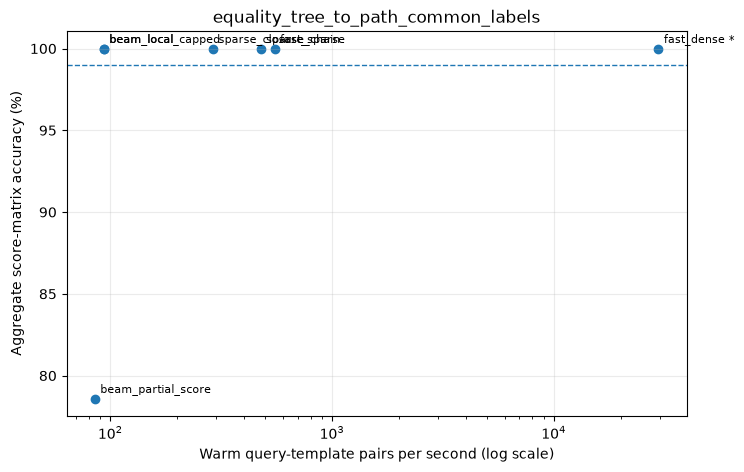

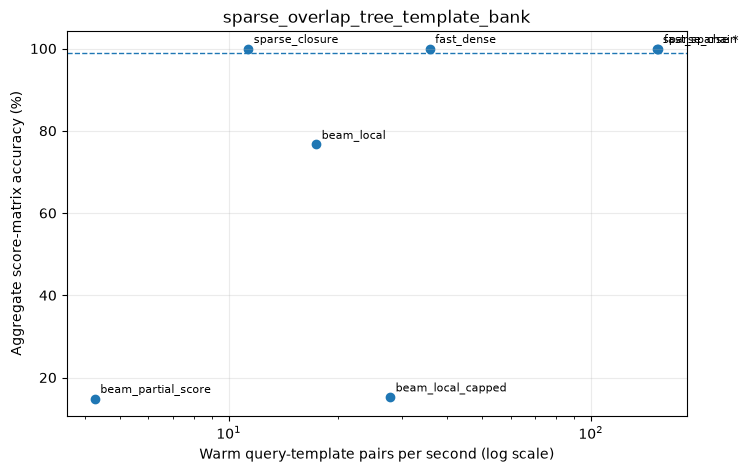

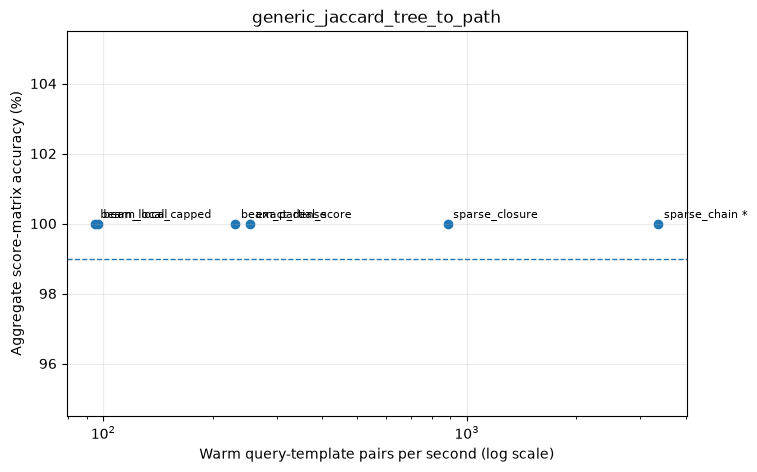

In [7]:
for regime_name in [item["name"] for item in config["regimes"]]:
    plot_data = compact[
        (compact["regime"] == regime_name)
        & compact["pairs_per_second"].notna()
        & compact["matrix_total_accuracy_percent"].notna()
        & (compact["pairs_per_second"] > 0.0)
    ].copy()
    if plot_data.empty:
        print(f"{regime_name}: no exact-oracle accuracy plot")
        continue

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    ax.scatter(plot_data["pairs_per_second"], plot_data["matrix_total_accuracy_percent"])
    for _, point in plot_data.iterrows():
        marker = " *" if bool(point["throughput_frontier"]) else ""
        ax.annotate(
            f"{point['algorithm']}{marker}",
            (point["pairs_per_second"], point["matrix_total_accuracy_percent"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
    ax.axhline(100.0 * float(config["quality_floor"]), linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_xlabel("Warm query-template pairs per second (log scale)")
    ax.set_ylabel("Aggregate score-matrix accuracy (%)")
    ax.set_title(regime_name)
    ax.grid(True, alpha=0.25)
    plt.show()

## One-time preparation, warm search, and process resources

Reusable preprocessing can change the relative ordering when one template bank
is queried repeatedly.  This table keeps setup components separate, and the
standard preset additionally reports fresh-process total time and peak resident
memory rather than folding them into warm throughput.


In [8]:
setup_columns = [
    "regime", "algorithm", "matcher_construction_seconds", "encoder_fit_seconds",
    "query_preparation_seconds", "template_preparation_seconds",
    "one_time_preparation_seconds", "score_matrix_seconds_median",
    "score_matrix_seconds_q25", "score_matrix_seconds_q75",
    "setup_plus_one_matrix_seconds", "cold_one_time_preparation_seconds",
    "cold_score_matrix_seconds", "cold_setup_plus_one_matrix_seconds",
    "fresh_process_total_seconds",
    "peak_rss_mib",
]
setup_columns = [column for column in setup_columns if column in summary.columns]
setup_table = summary[summary["status"] == "ok"][setup_columns].copy()
display(setup_table.sort_values(["regime", "setup_plus_one_matrix_seconds"]))


,regime,algorithm,matcher_construction_seconds,encoder_fit_seconds,query_preparation_seconds,template_preparation_seconds,one_time_preparation_seconds,score_matrix_seconds_median,score_matrix_seconds_q25,score_matrix_seconds_q75,setup_plus_one_matrix_seconds,cold_one_time_preparation_seconds,cold_score_matrix_seconds,cold_setup_plus_one_matrix_seconds,fresh_process_total_seconds,peak_rss_mib
1,equality_tree_to_path_common_labels,fast_dense,0.000023,0.002266,0.003510,0.000105,0.005904,0.016185,0.016154,0.016194,0.022089,0.005981,0.117516,0.123497,0.468882,191.546875
4,equality_tree_to_path_common_labels,fast_sparse,0.000029,0.002240,0.010063,0.000302,0.012634,0.872449,0.870876,0.872528,0.885083,0.012886,0.869632,0.882518,3.782458,189.703125
3,equality_tree_to_path_common_labels,sparse_chain,0.000027,0.000000,0.008457,0.000322,0.008806,1.008694,1.008566,1.011021,1.017501,0.010171,1.016081,1.026253,4.361668,189.703125
2,equality_tree_to_path_common_labels,sparse_closure,0.000025,0.000000,0.008237,0.000318,0.008580,1.651825,1.648990,1.654224,1.660405,0.009575,1.650441,1.660016,6.923114,189.890625
5,equality_tree_to_path_common_labels,beam_local,0.000017,0.000000,0.000000,0.000000,0.000017,5.127057,5.126970,5.129423,5.127074,0.000018,5.128695,5.128713,20.893893,189.890625
6,equality_tree_to_path_common_labels,beam_local_capped,0.000019,0.000000,0.000000,0.000000,0.000019,5.149083,5.095482,5.158665,5.149102,0.000017,5.164172,5.164190,20.897099,189.890625
7,equality_tree_to_path_common_labels,beam_partial_score,0.000021,0.000000,0.000000,0.000000,0.000021,5.644830,5.644400,5.651987,5.644851,0.000021,5.600076,5.600096,22.931294,189.890625
19,generic_jaccard_tree_to_path,sparse_chain,0.000013,0.000000,0.004698,0.000268,0.004979,0.047575,0.047562,0.047631,0.052554,0.006048,0.047391,0.053439,0.437199,201.703125
18,generic_jaccard_tree_to_path,sparse_closure,0.000017,0.000000,0.004824,0.000282,0.005123,0.180743,0.180501,0.180929,0.185866,0.006177,0.181553,0.187730,0.994099,201.703125
16,generic_jaccard_tree_to_path,exact_dense,0.000016,0.000000,0.000000,0.000000,0.000016,0.630682,0.629058,0.631380,0.630698,0.000017,0.631525,0.631542,2.802617,201.703125


## Sampled algorithmic work counters

Diagnostics are collected on a small deterministic sample of pairs outside the
clean timing loop. Blank entries mean that a counter is not meaningful for that
algorithm.

In [9]:
diagnostic_columns = [
    column for column in summary.columns
    if column.startswith("sample_median_diag_")
    and summary[column].notna().any()
]
work_table = summary[[
    "regime", "algorithm", "diagnostic_pairs_checked", *diagnostic_columns
]].copy()
display(work_table)

,regime,algorithm,diagnostic_pairs_checked,sample_median_diag_candidate_generation_seconds,sample_median_diag_directions,sample_median_diag_dp_cells_computed,sample_median_diag_input_preprocessing_seconds,sample_median_diag_n_g,sample_median_diag_n_h,sample_median_diag_node_pair_score_evaluations,sample_median_diag_preprocessing_seconds,sample_median_diag_restarts,sample_median_diag_result_length,sample_median_diag_result_score,sample_median_diag_search_seconds,sample_median_diag_total_seconds,sample_median_diag_traceback_seconds,sample_median_diag_candidate_pairs_generated,sample_median_diag_extra_candidate_pairs_after_deduplication,sample_median_diag_extra_candidate_states_created,sample_median_diag_extra_segment_tree_interval_insertions,sample_median_diag_extra_segment_tree_node_update_attempts,sample_median_diag_extra_segment_tree_peak_rollback_history,sample_median_diag_extra_segment_tree_point_queries,sample_median_diag_extra_segment_tree_successful_node_updates,sample_median_diag_positive_candidate_pairs,sample_median_diag_extra_candidate_pairs_after_token_deduplication,sample_median_diag_extra_posting_hits,sample_median_diag_extra_beam_width,sample_median_diag_extra_child_cap,sample_median_diag_extra_maximum_product_layer,sample_median_diag_extra_permanent_state_pool_size,sample_median_diag_layers_processed,sample_median_diag_peak_frontier_size,sample_median_diag_states_after_endpoint_pruning,sample_median_diag_states_generated,sample_median_diag_states_retained,sample_median_diag_extra_label_pair_preprocessing_score_evaluations,sample_median_diag_extra_lookahead_score_evaluations,sample_median_diag_extra_selected_restart,sample_median_diag_extra_stored_score_cells
0,equality_tree_to_path_common_labels,exact_dense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,equality_tree_to_path_common_labels,fast_dense,5.0,0.000000,1.0,6720.0,0.000000,280.0,24.0,6720.0,0.000004,1.0,11.0,11.000000,0.000022,0.000041,7.891998e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,equality_tree_to_path_common_labels,sparse_closure,5.0,0.000096,1.0,5215.0,0.000002,280.0,24.0,886.0,0.000058,1.0,11.0,11.000000,0.003313,0.003526,3.883993e-06,886.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,886.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5479.0
3,equality_tree_to_path_common_labels,sparse_chain,5.0,0.000329,1.0,NaN,0.000002,280.0,24.0,886.0,0.000306,1.0,11.0,11.000000,0.001275,0.001955,8.599891e-07,886.0,886.0,886.0,878.0,2391.0,76.0,886.0,925.0,886.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,equality_tree_to_path_common_labels,fast_sparse,5.0,0.000062,1.0,NaN,0.000000,280.0,24.0,886.0,0.000310,1.0,11.0,11.000000,0.001282,0.001710,8.220086e-07,886.0,886.0,886.0,878.0,2391.0,76.0,886.0,925.0,886.0,886.0,886.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,equality_tree_to_path_common_labels,beam_local,5.0,0.009622,1.0,NaN,0.000002,280.0,24.0,5803.0,0.000040,1.0,11.0,11.000000,0.002104,0.011844,2.059009e-06,5803.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,786.0,NaN,NaN,200.0,NaN,41.0,5786.0,42.0,200.0,6335.0,17356.0,5785.0,NaN,NaN,NaN,NaN
6,equality_tree_to_path_common_labels,beam_local_capped,5.0,0.009451,1.0,NaN,0.000002,280.0,24.0,5803.0,0.000040,1.0,11.0,11.000000,0.002068,0.011641,2.033979e-06,5803.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,786.0,NaN,NaN,200.0,16.0,41.0,5786.0,42.0,200.0,6335.0,17356.0,5785.0,NaN,NaN,NaN,NaN
7,equality_tree_to_path_common_labels,beam_partial_score,5.0,0.009903,1.0,NaN,0.000002,280.0,24.0,4558.0,0.000311,1.0,8.0,8.000000,0.001602,0.011968,1.075008e-06,4101.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4101.0,NaN,NaN,NaN,NaN,NaN,NaN,9.0,200.0,904.0,4101.0,819.0,144.0,0.0,0.0,NaN
8,sparse_overlap_tree_template_bank,exact_dense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## Save notebook-facing tables

The backend has already saved the complete result rows, metadata, and compressed
score matrices. This cell adds the compact tables displayed above and a copy of
the exact notebook configuration.

In [10]:
output_dir.mkdir(parents=True, exist_ok=True)
compact.to_csv(output_dir / "notebook_throughput_table.csv", index=False)
regime_summary.to_csv(output_dir / "notebook_regime_summary.csv", index=False)
setup_table.to_csv(output_dir / "notebook_setup_table.csv", index=False)
work_table.to_csv(output_dir / "notebook_work_summary.csv", index=False)
(output_dir / "notebook_config.json").write_text(
    json.dumps(config, indent=2, sort_keys=True, default=str),
    encoding="utf-8",
)

print("Saved:")
for name in (
    "throughput_rows.csv",
    "throughput_summary.csv",
    "throughput_metadata.json",
    "throughput_score_matrices.npz",
    "notebook_throughput_table.csv",
    "notebook_regime_summary.csv",
    "notebook_setup_table.csv",
    "notebook_work_summary.csv",
    "notebook_config.json",
):
    print(f"  {output_dir / name}")

Saved:
  /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_throughput_standard_standard_v1/throughput_rows.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_throughput_standard_standard_v1/throughput_summary.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_throughput_standard_standard_v1/throughput_metadata.json
  /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_throughput_standard_standard_v1/throughput_score_matrices.npz
  /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_throughput_standard_standard_v1/notebook_throughput_table.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_throughput_standard_standard_v1/notebook_regime_summary.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_throughput_standard_standard_v1/notebook_setup_table.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/path_match_thro

## Reading the result

Warm throughput answers the operational question after the template bank and
queries have been prepared. `setup_plus_one_matrix_seconds` answers whether that
preparation is worthwhile for a single score matrix.  Fresh-process total time
and peak resident memory are separate deployment-oriented measurements.  For a
recurring template bank, the warm result becomes increasingly relevant; for
one-off comparisons, the pairwise ranking notebook is the better summary.
